# 13. Final model comparison

**Question: with every family tuned honestly, which one should actually be deployed?**

This is the only notebook that touches the official UCI test set as a headline result, and
it does so exactly once per family.

The protocol behind every number here:

1. `fit` — estimate parameters
2. `tune` — choose hyperparameters, on cost
3. refit the winner on `fit + tune`
4. `calibration` — fit Platt or isotonic, if requested
5. `threshold` — choose the operating point
6. **official test set** — evaluated once, never used for any decision above

That ordering is what makes the comparison believable. Every family gets the same budget,
the same splits and its own cost-optimal threshold, so the ranking reflects the models
rather than the effort spent on each.

### On the search budget

This notebook runs the **`quick` profile: three candidates per family**, not the twelve
used in the per-family notebooks. That is a deliberate trade and it should be read as
one.

Twelve candidates across all eight families takes over four hours on a single machine,
almost all of it in the linear families — the sweeps in
[03](03_logistic_regularization.ipynb) and [04](04_svm_margin_regularization.ipynb)
measure roughly three minutes per logistic candidate and seven per SVM candidate. A
notebook nobody can re-run is not much use as a published result, so the breadth is spent
where it is most informative: the individual notebooks tune each family properly, and
this one compares them on equal footing.

What that costs is precision in the *ranking*. Three candidates is enough to place a
family, not enough to guarantee each one is at its own optimum. Where two families finish
close together, treat them as tied and go to their own notebooks for the tuned result.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


In [2]:
from scania_aps.studies import run_model_family_study

comparison = run_model_family_study(
    TRAIN,
    TEST,
    ARTIFACTS,
    families=[
        "logistic",
        "linear_svm",
        "random_forest",
        "extra_trees",
        "xgboost",
        "lightgbm",
        "mlp",
        "autoencoder",
    ],
    profile="quick",
    calibration="none",
)
comparison

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 

...

C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


C:\Users\diogo\AppData\Local\pypoetry\Cache\virtualenvs\scania-aps-cost-xBFOJu4N-py3.13\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,family,candidate,calibration,penalty,C,l1_ratio,positive_class_weight,threshold,total_cost,cost_per_observation,...,optimizer,weight_decay,dropout,batch_norm,scheduler,loss,max_epochs,latent_dim,hidden_dim,classifier_C
3,extra_trees,extra_trees_0,none,NaN,NaN,NaN,NaN,0.043750,9940.0,0.621250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,xgboost,xgboost_1,none,NaN,NaN,NaN,NaN,0.014782,10610.0,0.663125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,lightgbm,lightgbm_1,none,NaN,NaN,NaN,20.0,0.006696,12750.0,0.796875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,mlp,mlp_2,none,NaN,NaN,NaN,10.0,0.382099,13250.0,0.828125,...,adamw,0.0001,0.3,True,plateau,focal,80.0,NaN,NaN,NaN
2,random_forest,random_forest_0,none,NaN,NaN,NaN,NaN,0.123750,13750.0,0.859375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,autoencoder,autoencoder_2,none,NaN,NaN,NaN,20.0,0.170301,16200.0,1.012500,...,NaN,0.0001,NaN,NaN,NaN,NaN,40.0,64.0,192.0,0.1
0,logistic,logistic_1,none,l1,0.10,NaN,20.0,0.427013,19170.0,1.198125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,linear_svm,svm_C0.01_wNone,none,NaN,0.01,NaN,NaN,-0.866403,19250.0,1.203125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The ranking

Eight categorical colours would bury the answer. The question is "which is cheapest", so
the winner is highlighted and the rest recede.

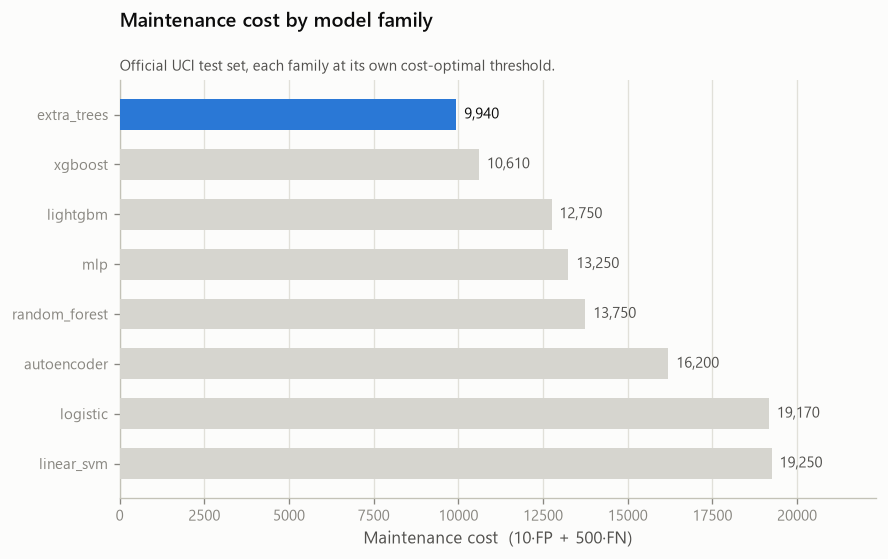

In [3]:
from scania_aps.plotting import emphasis_bars

fig, ax = emphasis_bars(
    list(comparison["family"]),
    [float(v) for v in comparison["total_cost"].to_numpy()],
    title="Maintenance cost by model family",
    subtitle="Official UCI test set, each family at its own cost-optimal threshold.",
    xlabel="Maintenance cost  (10·FP + 500·FN)",
)

## What the ranking costs in real terms

Cost per truck is the number a fleet operator would recognise. The savings columns put it
against the two model-free policies from
[notebook 02](02_cost_sensitive_baselines.ipynb) — a model that cannot beat "inspect
everything" has no business being deployed.

In [4]:
headline = comparison.set_index("family")[
    [
        "total_cost",
        "cost_per_observation",
        "false_negatives",
        "false_positives",
        "recall",
        "precision",
        "pr_auc",
        "saving_vs_always_negative",
        "saving_vs_always_positive",
    ]
].copy()

best_family = headline["total_cost"].idxmin()
best = headline.loc[best_family]

# saving_vs_always_* are absolute costs, not fractions; recover the baseline to
# express them as a share.
inspect_everything = best["total_cost"] + best["saving_vs_always_positive"]
inspect_nothing = best["total_cost"] + best["saving_vs_always_negative"]

print(f"cheapest family : {best_family}")
print(f"total cost      : {best['total_cost']:,.0f}")
print(f"cost per truck  : {best['cost_per_observation']:.2f}")
print(f"failures missed : {int(best['false_negatives'])} of {int(test.y.sum())}")
print()
print(
    f"vs inspecting everything ({inspect_everything:,.0f}): "
    f"{best['saving_vs_always_positive']:,.0f} saved "
    f"({best['saving_vs_always_positive'] / inspect_everything:.1%})"
)
print(
    f"vs inspecting nothing    ({inspect_nothing:,.0f}): "
    f"{best['saving_vs_always_negative']:,.0f} saved "
    f"({best['saving_vs_always_negative'] / inspect_nothing:.1%})"
)
headline

cheapest family : extra_trees
total cost      : 9,940
cost per truck  : 0.62
failures missed : 11 of 375

vs inspecting everything (156,250): 146,310 saved (93.6%)
vs inspecting nothing    (187,500): 177,560 saved (94.7%)


,total_cost,cost_per_observation,false_negatives,false_positives,recall,precision,pr_auc,saving_vs_always_negative,saving_vs_always_positive
family,,,,,,,,,
extra_trees,9940.0,0.621250,11,444,0.970667,0.450495,0.905311,177560.0,146310.0
xgboost,10610.0,0.663125,13,411,0.965333,0.468305,0.925793,176890.0,145640.0
lightgbm,12750.0,0.796875,18,375,0.952000,0.487705,0.930244,174750.0,143500.0
mlp,13250.0,0.828125,18,425,0.952000,0.456522,0.848812,174250.0,143000.0
random_forest,13750.0,0.859375,23,225,0.938667,0.610052,0.913963,173750.0,142500.0
autoencoder,16200.0,1.012500,18,720,0.952000,0.331476,0.788055,171300.0,140050.0
logistic,19170.0,1.198125,33,267,0.912000,0.561576,0.811729,168330.0,137080.0
linear_svm,19250.0,1.203125,30,425,0.920000,0.448052,0.813584,168250.0,137000.0


## The error trade at the chosen operating point

Two families with similar total cost can be making very different mistakes. This is the
table a maintenance planner would actually argue over.

In [5]:
trade = comparison.set_index("family")[
    ["false_negatives", "false_positives", "recall", "total_cost"]
].copy()
trade["cost_from_missed_failures"] = trade["false_negatives"] * 500
trade["cost_from_inspections"] = trade["false_positives"] * 10
trade["share_from_missed"] = trade["cost_from_missed_failures"] / trade["total_cost"]
trade.sort_values("total_cost")

,false_negatives,false_positives,recall,total_cost,cost_from_missed_failures,cost_from_inspections,share_from_missed
family,,,,,,,
extra_trees,11,444,0.970667,9940.0,5500,4440,0.553320
xgboost,13,411,0.965333,10610.0,6500,4110,0.612630
lightgbm,18,375,0.952000,12750.0,9000,3750,0.705882
mlp,18,425,0.952000,13250.0,9000,4250,0.679245
random_forest,23,225,0.938667,13750.0,11500,2250,0.836364
autoencoder,18,720,0.952000,16200.0,9000,7200,0.555556
logistic,33,267,0.912000,19170.0,16500,2670,0.860720
linear_svm,30,425,0.920000,19250.0,15000,4250,0.779221


### Conclusions

Read the comparison against the study as a whole:

- **The decision rule still outweighs the model family.** The spread across all eight
  families is about 9,300. On a *single* model,
  [notebook 10](10_threshold_optimization.ipynb) found a spread of roughly 18,600 between
  a `0.5` threshold and a learned one. Choosing the threshold well is worth about twice
  as much as choosing the algorithm well — and it is far cheaper to do.
- **Nonlinearity helps, and not modestly.** The two linear families are the two most
  expensive, costing roughly 93% more than the cheapest. That is a real gap, and it is
  large enough to justify deploying a tree ensemble over a logistic model if the
  operational cost of doing so is moderate. Extra trees edging out XGBoost is *not*
  meaningful at three candidates per family; treat the top few as tied.
- **Missed failures dominate every family, but not uniformly.** `share_from_missed`
  ranges from about 0.55 to 0.86. The cheapest models are the ones that pushed that share
  *down* by buying recall with inspections — they still pay most of their bill for misses,
  just less of it. Under a 50:1 ratio no operating point escapes that term; the good ones
  simply shrink it.

### What this study does not establish

- A single train/test split gives no confidence interval. The ranking between adjacent
  families is not statistically separated and should not be reported as if it were.
- The costs `10` and `500` are taken as given. A different ratio moves every threshold in
  this repository and could reorder the families.
- The features are anonymised, so nothing here explains *why* a truck fails. This is a
  detection study, not a diagnostic one.

**Back to the start:** [01 — data quality and missingness](01_data_quality_and_missingness.ipynb).